In [48]:
%pip install pandas matplotlib seaborn
%load_ext autoreload
%autoreload 2

Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Route Python to the main project folder
sys.path.append(os.path.abspath('..'))

# Import custom modules
from src.data_fetcher import load_airline_data
from src.data_profiling import generate_quality_report

# Set visual style for charts
sns.set_theme(style="whitegrid")

In [50]:
# Load the raw dataset
df = load_airline_data()

# Preview the first 5 rows to understand the structure
display(df.head())

# Generate the initial quality report
generate_quality_report(df)

#print(df.columns.tolist())

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN



       DATA QUALITY REPORT

 Inside verify_duplicate_values method

Number of duplicate rows found: 0
No duplicate rows detected.
----------------------------------------

 Inside verify_missing_values method
--- Missing values per column ---
Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

--- Percentage of missing values ---
Loyalty Number         0.000000
Country                0.000000
Province               0.000000
City                   0.000000
Postal Code            0.000000
Gender                 0.000000
Education              0.000000
Salary                25.321145
M

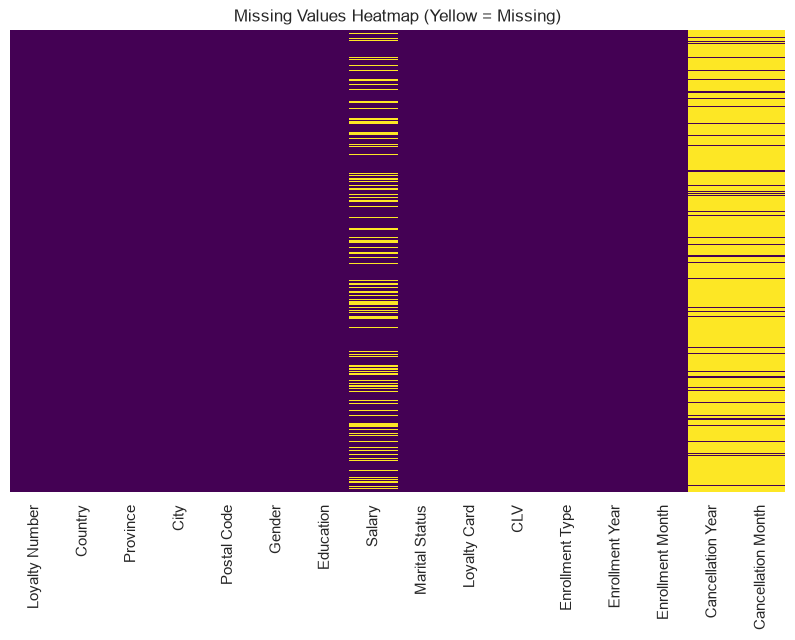

In [51]:
# Visualize null values across the dataset
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap (Yellow = Missing)")
plt.show()

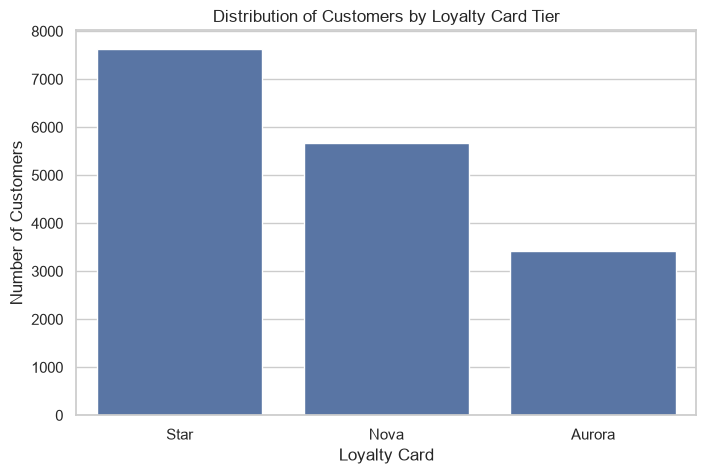

Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64

In [52]:
# Analyze the distribution of Loyalty Cards
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Loyalty Card', order=df['Loyalty Card'].value_counts().index)
plt.title("Distribution of Customers by Loyalty Card Tier")
plt.ylabel("Number of Customers")
plt.show()

# Print exact counts 
display(df['Loyalty Card'].value_counts())


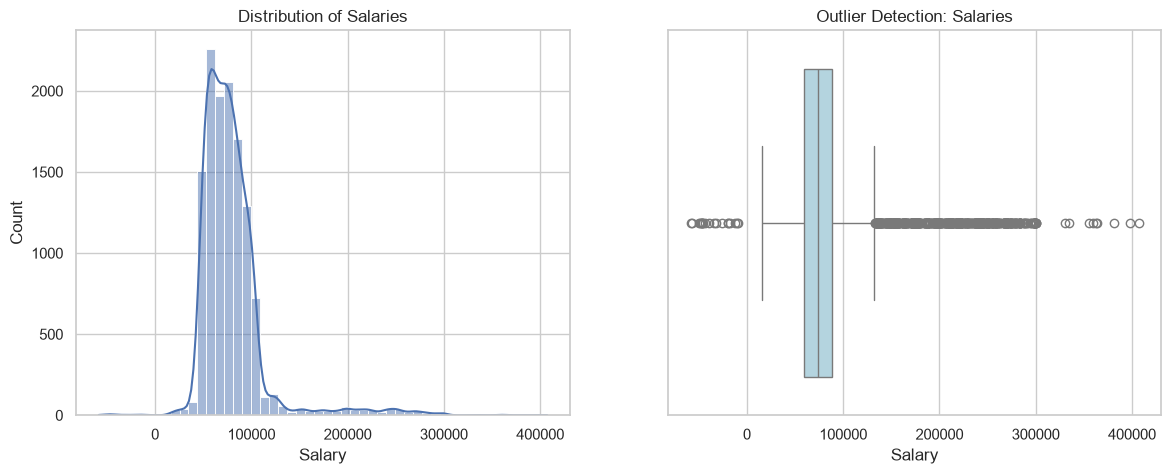

In [53]:
# Analyze Salary distributions and spot extreme outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for distribution
sns.histplot(df['Salary'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Salaries")

# Boxplot for outliers
sns.boxplot(x=df['Salary'], ax=axes[1], color='lightblue')
axes[1].set_title("Outlier Detection: Salaries")

plt.show()

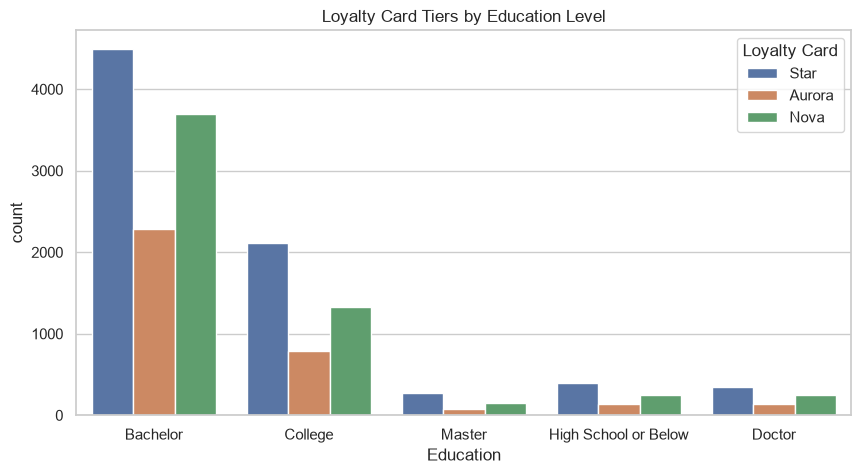

In [54]:
# Analyze which Loyalty Card tiers are held by different Education levels
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Education', hue='Loyalty Card')
plt.title("Loyalty Card Tiers by Education Level")
plt.show()

In [ ]:
total_records = len(df)
df['Churn'] = df['Cancellation Year'].notnull().map({True: 'Yes', False: 'No'})

# Explicitly exclude IDs or columns that overlap directly with the target
exclude_cols = ['Loyalty Number', 'Cancellation Year', 'Cancellation Month', 'Churn']

for col in df.columns:
    if col in exclude_cols:
        continue
        
    # Dynamically handle numbers vs. text
    if pd.api.types.is_numeric_dtype(df[col]):
        # If the number only has a few distinct values (like a year), treat as an integer
        if df[col].nunique() < 25:
            analyze_series = df[col].fillna(-1).round(0).astype(int).astype(str)
        else:
            # If it is highly continuous (like Salary), divide it into 5 even buckets
            analyze_series = pd.qcut(df[col], q=5, duplicates='drop').astype(str)
    else:
        # Leave categorical variables as they are
        analyze_series = df[col]

    # 1. Base counts using our adjusted series
    counts = df.groupby(analyze_series)['Churn'].value_counts().unstack().fillna(0).astype(int)
    
    # Ensure both 'Yes' and 'No' columns exist to prevent KeyError
    if 'Yes' not in counts.columns: counts['Yes'] = 0
    if 'No' not in counts.columns: counts['No'] = 0
        
    row_totals = counts.sum(axis=1)
    row_totals_pct = (row_totals / total_records * 100).round(2)

    # --- LIST 1: Sorted by Yes % (Normalized within row) ---
    pcts_norm = (df.groupby(analyze_series)['Churn'].value_counts(normalize=True).unstack().fillna(0) * 100).round(2)
    if 'Yes' not in pcts_norm.columns: pcts_norm['Yes'] = 0.0
    if 'No' not in pcts_norm.columns: pcts_norm['No'] = 0.0
        
    combined_norm = pd.DataFrame(index=counts.index)
    combined_norm['No(%)'] = counts['No'].astype(str) + " (" + pcts_norm['No'].astype(str) + "%)"
    combined_norm['Yes(%)'] = counts['Yes'].astype(str) + " (" + pcts_norm['Yes'].astype(str) + "%)"
    combined_norm['Total (%)'] = row_totals.astype(str) + " (" + row_totals_pct.astype(str) + "%)"

    # --- LIST 2: Global % (no_count/total and yes_count/total) sorted by yes_pct ---
    pcts_global = (counts / total_records * 100).round(2)
    combined_global = pd.DataFrame(index=counts.index)
    combined_global['No(%)'] = counts['No'].astype(str) + " (" + pcts_global['No'].astype(str) + "%)"
    combined_global['Yes(%)'] = counts['Yes'].astype(str) + " (" + pcts_global['Yes'].astype(str) + "%)"
    combined_global['Total (%)'] = row_totals.astype(str) + " (" + row_totals_pct.astype(str) + "%)"

    print(f"\n{'='*20} Feature: {col} {'='*20}")

    print("\n1) Sorted by Churn Rate (Normalized 'Yes %'):")
    display(combined_norm.assign(_s=pcts_norm['Yes']).sort_values('_s', ascending=False).drop(columns=['_s']))

    print("\n2) Sorted by Global 'Yes %' (Calculated vs. Overall Total):")
    display(combined_global.assign(_s=pcts_global['Yes']).sort_values('_s', ascending=False).drop(columns=['_s']))

In [57]:


def generate_refined_interaction_tables(df, output_folder='outputs/content/interaction_output'):
    os.makedirs(output_folder, exist_ok=True)
    
    # 1. Ensure the target variable exists
    if 'Churn' not in df.columns:
        df['Churn'] = df['Cancellation Year'].notnull().map({True: 'Yes', False: 'No'})

    # 2. Filter for categorical columns ONLY to prevent massive memory cross-joins
    base_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    
    exclude_cols = ['Loyalty Number', 'Cancellation Year', 'Cancellation Month', 'Churn']
    cols = [c for c in base_cols if c not in exclude_cols]

    def get_filtered_indices(series, top_n=10, percentile=90):
        sorted_s = series.sort_values(ascending=False)
        top_n_idx = sorted_s.head(top_n).index
        p_val = sorted_s.quantile(percentile / 100)
        p_idx = sorted_s[sorted_s >= p_val].index
        return p_idx if len(p_idx) >= len(top_n_idx) else top_n_idx

    for int_col in cols:
        for out_col in cols:
            # Skip if the columns are identical
            if int_col == out_col: 
                continue

            counts = df.groupby([int_col, out_col], observed=True)['Churn'].value_counts().unstack().fillna(0).astype(int)
            
            # Ensure proper capitalization matching our mapped 'Yes'/'No' target
            if 'Yes' not in counts.columns: continue
            if 'No' not in counts.columns: counts['No'] = 0

            totals = counts.sum(axis=1)
            global_total = totals.sum()
            
            # Skip empty combinations
            if global_total == 0: continue

            # S1: Row Normalized
            s1_yes_pct = (counts['Yes'] / totals * 100).round(2)
            s1_idx = get_filtered_indices(s1_yes_pct)
            s1_df = counts.loc[s1_idx].copy()
            s1_df['yes_pct'] = s1_yes_pct.loc[s1_idx]
            s1_df = s1_df.reset_index().sort_values(by=['yes_pct', int_col], ascending=[False, True])

            # S2: Global Normalized
            s2_yes_pct = (counts['Yes'] / global_total * 100).round(2)
            s2_idx = get_filtered_indices(s2_yes_pct)
            s2_df = counts.loc[s2_idx].copy()
            s2_df['yes_pct'] = s2_yes_pct.loc[s2_idx]
            s2_df = s2_df.reset_index().sort_values(by=['yes_pct', int_col], ascending=[False, True])

            final_rows = []

            # Section 1 Header & Data
            final_rows.append({int_col: f'--- SCENARIO 1', out_col: '(Row Normalized) ---', 'No (%)': '', 'Yes (%)': '', 'Total (%)': ''})
            for _, row in s1_df.iterrows():
                row_sum = row['No'] + row['Yes']
                final_rows.append({
                    int_col: str(row[int_col]),
                    out_col: str(row[out_col]),
                    'No (%)': f"{row['No']} ({(row['No']/row_sum*100):.2f}%)",
                    'Yes (%)': f"{row['Yes']} ({row['yes_pct']:.2f}%)",
                    'Total (%)': f"{row_sum} (100.0%)"
                })

            # Section 2 Header & Data
            final_rows.append({int_col: f'--- SCENARIO 2', out_col: '(Global Normalized) ---', 'No (%)': '', 'Yes (%)': '', 'Total (%)': ''})
            for _, row in s2_df.iterrows():
                row_sum = row['No'] + row['Yes']
                final_rows.append({
                    int_col: str(row[int_col]),
                    out_col: str(row[out_col]),
                    'No (%)': f"{row['No']} ({(row['No']/global_total*100):.2f}%)",
                    'Yes (%)': f"{row['Yes']} ({row['yes_pct']:.2f}%)",
                    'Total (%)': f"{row_sum} ({(row_sum/global_total*100):.2f}%)"
                })

            output_df = pd.DataFrame(final_rows)
            fname = f"interaction_{int_col}_vs_{out_col}_refined.csv"
            output_df.to_csv(os.path.join(output_folder, fname), index=False)

    print(f"Refined tables generated in {output_folder}")

# Execute the function
generate_refined_interaction_tables(df)

C:\Users\echatma\AppData\Local\Temp\ipykernel_34104\3029089905.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  base_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Refined tables generated in outputs/content/interaction_output
